# Introduction

**Install dependencies**

Installs the Darts package required for time-series analysis.


In [22]:
%pip install -q darts


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


**Inspect NumPy correlation help**

Imports NumPy and displays the documentation for numpy.coeff


In [23]:
import numpy as np

print(help(np.corrcoef))

Help on _ArrayFunctionDispatcher in module numpy:

corrcoef(x, y=None, rowvar=True, bias=<no value>, ddof=<no value>, *, dtype=None)
    Return Pearson product-moment correlation coefficients.
    
    Please refer to the documentation for `cov` for more detail.  The
    relationship between the correlation coefficient matrix, `R`, and the
    covariance matrix, `C`, is
    
    .. math:: R_{ij} = \frac{ C_{ij} } { \sqrt{ C_{ii} C_{jj} } }
    
    The values of `R` are between -1 and 1, inclusive.
    
    Parameters
    ----------
    x : array_like
        A 1-D or 2-D array containing multiple variables and observations.
        Each row of `x` represents a variable, and each column a single
        observation of all those variables. Also see `rowvar` below.
    y : array_like, optional
        An additional set of variables and observations. `y` has the same
        shape as `x`.
    rowvar : bool, optional
        If `rowvar` is True (default), then each row represents a
       

**Load the dataset**

Reads the cleaned CSV file into a pandas DataFrame and previews its first five rows.


In [24]:
import pandas as pd

file_path = "../Data/dropout_clean_new.csv"

df = pd.read_csv(file_path)
print(df[0:5])

     Student ID  Dropout (1=Yes 0=No)   Degree Code  Study Mode  Entry Year  \
0  0002ccc8623e                     0  ec2e990b934d           1      2021.0   
1  00075bbc7af3                     0  bb668ca95563           1      2022.0   
2  0008337bd791                     0  1d0ebea552eb           1      2020.0   
3  000be0ddb26c                     0  d6a403173361           1      2022.0   
4  000d5aac651d                     0  0fecf9247f3d           1      2019.0   

  Admission Type  Active Enrollment  Displaced Student Second Degree Student  \
0            BMA                  1                  1                   NaN   
1            NCA                  1                  0                   1,0   
2            NAP                  1                  0                   NaN   
3            NAP                  1                  1                   NaN   
4            NAP                  1                  1                   NaN   

   Overall Pass Rate (%)  ...  Platform Even

**Check index uniqueness**

Verifies whether every row in the DataFrame has a unique index value.


In [25]:
df.index.is_unique


True

**Remove missing values**

Creates a cleaned DataFrame by dropping rows that contain missing values.


In [26]:
df_cleaned = pd.DataFrame.dropna(df)

print(df_cleaned)

Empty DataFrame
Columns: [Student ID, Dropout (1=Yes 0=No), Degree Code, Study Mode, Entry Year, Admission Type, Active Enrollment, Displaced Student, Second Degree Student, Overall Pass Rate (%), Pass Rate Semester A (%), Pass Rate Semester B (%), Pass Rate Last Year (%), Pass Rate 2 Years Ago (%), Credits Enrolled Total, Credits Passed Total, Credits Passed Normal, Credits Passed Sem A, Credits Passed Sem B, Credits Pending Grade, Lowest Year of Study, Highest Year of Study, Unpaid Fees Flag, Platform Days Logged (Total), Platform Events (Total), Platform Minutes (Total), Platform Visits (Total), Campus WiFi Days (Total), Resource Access Days (Total), Assignment Submissions (Total), Test Submissions (Total), Performance Bucket, Engagement Level, Credits Enrolled Band]
Index: []

[0 rows x 34 columns]


**Remove the student identifier**

Drops the `Student ID` column because an identifier is not useful for correlation analysis.


In [27]:
label = "Student ID"
df_without_studentid = df.drop(columns=label)
print(df_without_studentid)

       Dropout (1=Yes 0=No)   Degree Code  Study Mode  Entry Year  \
0                         0  ec2e990b934d           1      2021.0   
1                         0  bb668ca95563           1      2022.0   
2                         0  1d0ebea552eb           1      2020.0   
3                         0  d6a403173361           1      2022.0   
4                         0  0fecf9247f3d           1      2019.0   
...                     ...           ...         ...         ...   
20422                     0  5ec1a0c99d42           1         NaN   
20423                     1  01d54579da44           1      2022.0   
20424                     0  2c7d5490e605           1      2019.0   
20425                     0  7559ca4a957c           1      2021.0   
20426                     0  38b2d03f3256           1      2020.0   

      Admission Type  Active Enrollment  Displaced Student  \
0                BMA                  1                  1   
1                NCA                  1        

**Remove non-numeric categories**

Drops categorical code columns that should not be included directly in the numeric correlation matrix.


In [28]:
label1 = ["Degree Code", "Admission Type"]
df_all_ints = df_without_studentid.drop(columns=label1)
print(df_all_ints)

       Dropout (1=Yes 0=No)  Study Mode  Entry Year  Active Enrollment  \
0                         0           1      2021.0                  1   
1                         0           1      2022.0                  1   
2                         0           1      2020.0                  1   
3                         0           1      2022.0                  1   
4                         0           1      2019.0                  1   
...                     ...         ...         ...                ...   
20422                     0           1         NaN                  0   
20423                     1           1      2022.0                  0   
20424                     0           1      2019.0                  0   
20425                     0           1      2021.0                  1   
20426                     0           1      2020.0                  1   

       Displaced Student Second Degree Student  Overall Pass Rate (%)  \
0                      1              

**Convert values to numeric data**

Replaces decimal commas with decimal points and converts every remaining column to a numeric type.


In [29]:
df_all_ints = df_all_ints.replace(",", ".", regex=True)
df_all_ints = df_all_ints.apply(pd.to_numeric)

**Inspect the numeric dataset**

Displays the prepared DataFrame before calculating correlations.


In [30]:
print(df_all_ints)

       Dropout (1=Yes 0=No)  Study Mode  Entry Year  Active Enrollment  \
0                         0           1      2021.0                  1   
1                         0           1      2022.0                  1   
2                         0           1      2020.0                  1   
3                         0           1      2022.0                  1   
4                         0           1      2019.0                  1   
...                     ...         ...         ...                ...   
20422                     0           1         NaN                  0   
20423                     1           1      2022.0                  0   
20424                     0           1      2019.0                  0   
20425                     0           1      2021.0                  1   
20426                     0           1      2020.0                  1   

       Displaced Student  Second Degree Student  Overall Pass Rate (%)  \
0                      1             

**Calculate the correlation matrix**

Computes pairwise Pearson correlations between numeric variables and prints the result.


In [31]:
corr_matrix = df_all_ints.corr() 

print(corr_matrix)


                                Dropout (1=Yes 0=No)  Study Mode  Entry Year  \
Dropout (1=Yes 0=No)                        1.000000   -0.093341    0.031911   
Study Mode                                 -0.093341    1.000000    0.064265   
Entry Year                                  0.031911    0.064265    1.000000   
Active Enrollment                          -0.346569    0.011546    0.300293   
Displaced Student                           0.007024   -0.050217   -0.071345   
Second Degree Student                            NaN         NaN         NaN   
Overall Pass Rate (%)                      -0.331713    0.134171    0.230680   
Pass Rate Semester A (%)                   -0.205245    0.161699    0.098113   
Pass Rate Semester B (%)                   -0.325803    0.117286    0.251338   
Pass Rate Last Year (%)                    -0.129342    0.082395    0.383761   
Pass Rate 2 Years Ago (%)                  -0.139705    0.060820    0.381699   
Credits Enrolled Total                  

**Plot a basic correlation matrix**

Uses Matplotlib to display the complete correlation matrix as a color-coded image.


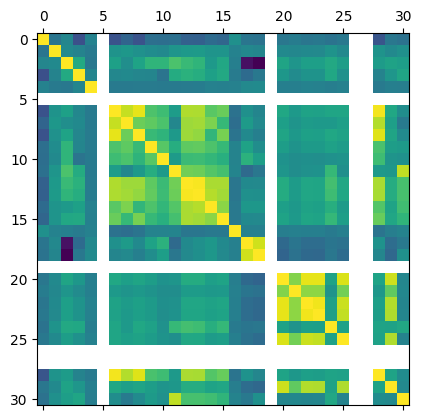

In [32]:
import matplotlib.pyplot as plt

plt.matshow(corr_matrix)
plt.show()

**Plot a detailed correlation heatmap**

Uses Seaborn to show annotated correlation values with a centered diverging color scale.


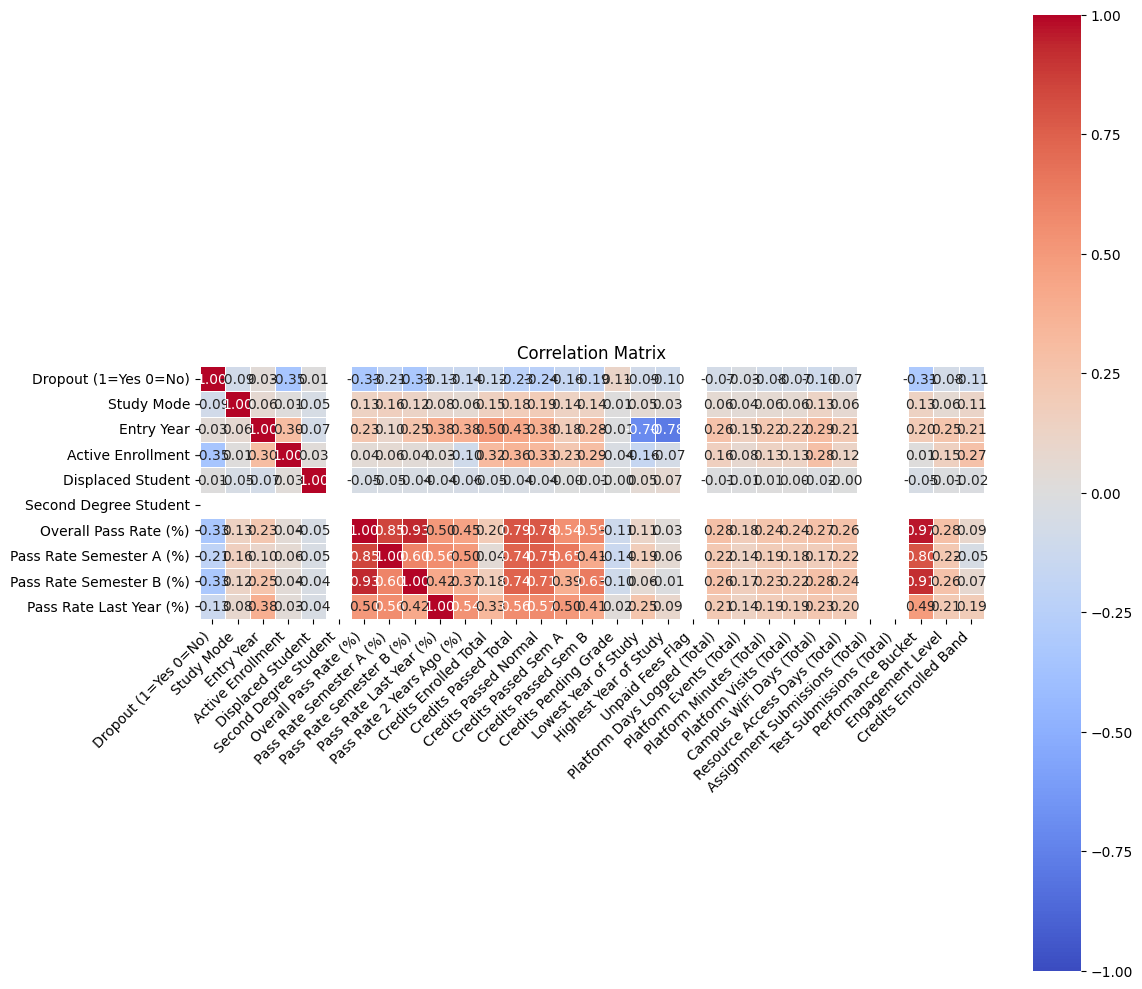

In [33]:
import seaborn as sns

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix[0:10],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()